In [1]:
pip install umap-learn scikit-learn pandas matplotlib

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


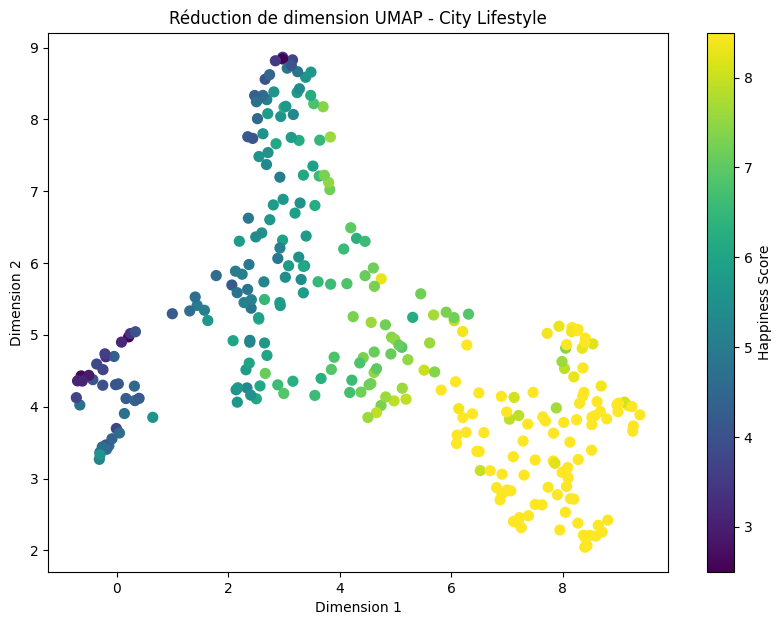

OSError: Cannot save file into a non-existent directory: '../outputs'

In [5]:
import pandas as pd
import umap
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# 1. Chargement des données
# Assure-toi que le fichier est bien dans le dossier 'data/' de ton projet
df = pd.read_csv('city_lifestyle_dataset.csv')

# 2. Nettoyage : On ne garde que les colonnes numériques pour l'algorithme
# On exclut 'city_name' et 'country' qui sont des textes
X = df.select_dtypes(include=['float64', 'int64'])

# 3. Standardisation (Étape cruciale pour UMAP)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Application de UMAP
# n_neighbors et min_dist sont les hyperparamètres principaux de UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
embedding = reducer.fit_transform(X_scaled)

# 5. Création du DataFrame de sortie
df_umap = pd.DataFrame(data=embedding, columns=['comp_1', 'comp_2'])

# 6. Visualisation
plt.figure(figsize=(10, 7))
# On colorise par 'happiness_score' pour voir si une structure émerge
plt.scatter(df_umap['comp_1'], df_umap['comp_2'], c=df['happiness_score'], cmap='viridis', s=50)
plt.colorbar(label='Happiness Score')
plt.title('Réduction de dimension UMAP - City Lifestyle')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.show()

# 7. EXPORTATION (Obligatoire pour la suite du projet)
df_umap.to_csv('umap_emb_2d.csv', index=False)
print("Fichier exporté dansumap_emb_2d.csv")

La projection UMAP montre plusieurs groupes bien distincts. On observe un gradient clair du score de bonheur : les points avec des scores élevés sont plutôt regroupés à droite, tandis que les scores plus faibles se trouvent davantage à gauche.
Les villes ayant des caractéristiques similaires semblent proches dans l’espace réduit, ce qui indique que UMAP a bien préservé la structure locale des données. Globalement, la méthode met bien en évidence des clusters cohérents liés au niveau de bonheur.

In [9]:

output_path = 'umap_emb_2d.csv'
df_umap.to_csv(output_path, index=False)